In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("run_results.csv")

In [3]:
df.describe()

,d_model,model_depth,head_dimension,n_heads,d_ffn,vocab_size,n_params_embedding,n_params_encoder,n_params_decoder,n_params_mha,...,embedding_matrix_lr,attention_weight_matrix_lr,attention_bias_lr,w_ffn_in_lr,w_ffn_out_lr,bias_lr,unembedding_matrix_lr,final_loss,best_loss,training_wall_time
count,954.00000,954.0,954.0,954.000000,954.00000,954.0,9.540000e+02,9.540000e+02,9.540000e+02,9.540000e+02,...,954.000000,9.540000e+02,954.000000,9.540000e+02,9.540000e+02,954.000000,9.540000e+02,954.000000,954.000000,954.000000
mean,363.60587,24.0,128.0,2.840671,1454.42348,32128.0,1.168193e+07,1.168193e+07,1.168193e+07,2.046454e+05,...,0.036254,1.727475e-04,0.036254,1.727475e-04,4.318687e-05,0.036254,1.727475e-04,7.371455,5.911634,25057.699481
std,269.28092,0.0,0.0,2.103757,1077.12368,0.0,8.651457e+06,8.651457e+06,8.651457e+06,2.988845e+05,...,0.048894,3.338531e-04,0.048894,3.338531e-04,8.346329e-05,0.048894,3.338531e-04,29.516227,26.567666,34890.498727
min,128.00000,24.0,128.0,1.000000,512.00000,32128.0,4.112384e+06,4.112384e+06,4.112384e+06,1.638400e+04,...,0.000977,9.536743e-07,0.000977,9.536743e-07,2.384186e-07,0.000977,9.536743e-07,2.975324,2.975324,486.828972
25%,128.00000,24.0,128.0,1.000000,512.00000,32128.0,4.112384e+06,4.112384e+06,4.112384e+06,1.638400e+04,...,0.006201,1.779982e-05,0.006201,1.779982e-05,4.449955e-06,0.006201,1.779982e-05,3.386637,3.386637,3116.520226
50%,256.00000,24.0,128.0,2.000000,1024.00000,32128.0,8.224768e+06,8.224768e+06,8.224768e+06,6.553600e+04,...,0.017948,5.232202e-05,0.017948,5.232202e-05,1.308051e-05,0.017948,5.232202e-05,3.838328,3.832620,13898.237037
75%,512.00000,24.0,128.0,4.000000,2048.00000,32128.0,1.644954e+07,1.644954e+07,1.644954e+07,2.621440e+05,...,0.039373,1.661121e-04,0.039373,1.661121e-04,4.152802e-05,0.039373,1.661121e-04,4.469299,4.298937,26939.946151
max,1024.00000,24.0,128.0,8.000000,4096.00000,32128.0,3.289907e+07,3.289907e+07,3.289907e+07,1.048576e+06,...,0.250000,1.953125e-03,0.250000,1.953125e-03,4.882812e-04,0.250000,1.953125e-03,374.245812,374.018747,142451.827808


In [4]:
print(df.columns)

Index(['d_model', 'model_depth', 'head_dimension', 'n_heads', 'd_ffn',
       'vocab_size', 'n_params_embedding', 'n_params_encoder',
       'n_params_decoder', 'n_params_mha', 'n_params_rms_norm', 'n_params_ffn',
       'n_params_transformer_block', 'n_parameters', 'base_lr', 'init_stddev',
       'absolute_init_stddev', 'max_lr', 'lr_schedule_name', 'optim_name',
       'optim_beta1', 'optim_beta2', 'optim_eps', 'weight_decay',
       'n_training_tokens', 'tokens_per_global_batch', 'batch_size',
       'sequence_len', 'n_pretrain_step', 'n_warmup_step',
       'embedding_matrix_lr', 'attention_weight_matrix_lr',
       'attention_bias_lr', 'w_ffn_in_lr', 'w_ffn_out_lr', 'bias_lr',
       'unembedding_matrix_lr', 'run_id', 'run_folder_path',
       'run_losses_df_path', 'final_loss', 'best_loss', 'training_wall_time',
       'lr_schedule_mode'],
      dtype='object')


In [5]:
print(df['n_pretrain_step'].unique())
print(df['n_training_tokens'].unique())
print(df['n_parameters'].unique())
print(df['lr_schedule_mode'].unique())

[89208.  3591.  9342. 27324.]
[5.84630272e+09 2.35335680e+08 6.12229120e+08 1.79068928e+09]
[ 11766784  30611456  89534464 292315136]
['clipping' 'relative']


In [6]:
# calculate effective learning rate (base_lr * sqrt(n_training_tokens))
df['effective_lr'] = df['base_lr'] * np.sqrt(df['n_training_tokens'])

In [7]:
# create column that states whether model was trained to full length or not
df['full_length_training'] = df['n_training_tokens'] == 5.84630272e+09

# split into relative and not relative df
df_relative = df[df['lr_schedule_mode'] == 'relative']
df_not_relative = df[df['lr_schedule_mode'] != "relative"]

# take best runs for each learning rate (different initialization variances)
df_best_runs_not_relative = (
    df_not_relative
    .sort_values(by="final_loss", ascending=True)
    .drop_duplicates(subset=["base_lr", "d_model", "full_length_training"], keep="first")
)
df_best_runs_relative = (
    df_relative
    .sort_values(by="final_loss", ascending=True)
    .drop_duplicates(subset=["base_lr", "d_model", "full_length_training"], keep="first")
)

# take optimal lr for optimum plotting
df_optimal_lrs_not_relative = (
    df_best_runs_not_relative
    .sort_values(by="final_loss", ascending=True)
    .drop_duplicates(subset=["d_model", "full_length_training"], keep="first")
)
df_optimal_lrs_relative = (
    df_best_runs_relative
    .sort_values(by="final_loss", ascending=True)
    .drop_duplicates(subset=["d_model", "full_length_training"], keep="first")
)

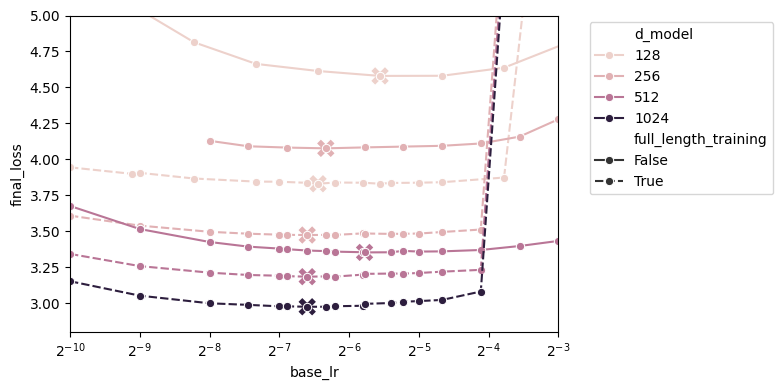

In [23]:
fig, ax = plt.subplots(1, 1, figsize=(8, 4))

# final loss
sns.lineplot(df_best_runs_not_relative,
    x="base_lr",
    y="final_loss",
    hue='d_model',
    style='full_length_training',
    ax=ax,
    marker='o',
    )

sns.scatterplot(
    df_optimal_lrs_not_relative,
    x='base_lr',
    y='final_loss',
    hue='d_model',
    ax=ax,
    marker='X',
    legend=False,
    s=200,
)

ax.set_xscale('log', base=2)
ax.set_xlim(2**-10, 2**-3)
ax.set_ylim(2.8, 5)

# Place outside the chart to the right
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

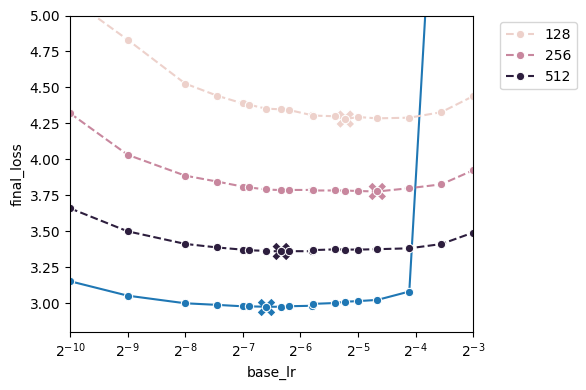

In [22]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))

# final loss
sns.lineplot(df_best_runs_not_relative.query("d_model == 1024"),
    x="base_lr",
    y="final_loss",
    # hue='d_model',
    # style='full_length_training',
    ax=ax,
    marker='o',
    )

sns.scatterplot(
    df_optimal_lrs_not_relative.query("d_model == 1024"),
    x='base_lr',
    y='final_loss',
    # hue='d_model',
    ax=ax,
    marker='X',
    legend=False,
    s=200,
)

# relative shorter trainings
sns.lineplot(df_best_runs_relative,
    x="base_lr",
    y="final_loss",
    hue='d_model',
    # style='full_length_training',
    ax=ax,
    linestyle='--',
    marker='o',
    )

sns.scatterplot(
    df_optimal_lrs_relative,
    x='base_lr',
    y='final_loss',
    hue='d_model',
    ax=ax,
    marker='X',
    legend=False,
    s=200,
)


ax.set_xscale('log', base=2)
ax.set_xlim(2**-10, 2**-3)
ax.set_ylim(2.8, 5)

# Place outside the chart to the right
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

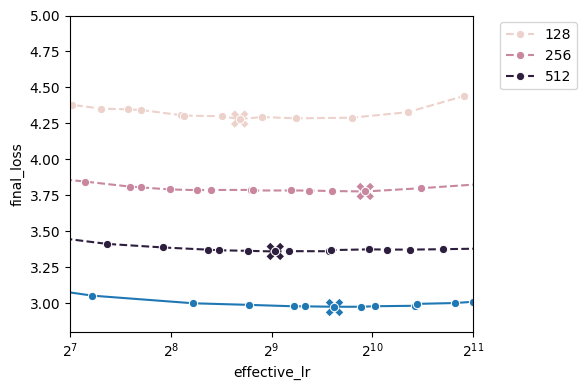

In [21]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))

# final loss
sns.lineplot(df_best_runs_not_relative.query("d_model == 1024"),
    x="effective_lr",
    y="final_loss",
    # hue='d_model',
    # style='full_length_training',
    ax=ax,
    marker='o',
    )

sns.scatterplot(
    df_optimal_lrs_not_relative.query("d_model == 1024"),
    x='effective_lr',
    y='final_loss',
    # hue='d_model',
    ax=ax,
    marker='X',
    legend=False,
    s=200,
)

# relative shorter trainings
sns.lineplot(df_best_runs_relative,
    x="effective_lr",
    y="final_loss",
    hue='d_model',
    # style='full_length_training',
    ax=ax,
    linestyle='--',
    marker='o',
    )

sns.scatterplot(
    df_optimal_lrs_relative,
    x='effective_lr',
    y='final_loss',
    hue='d_model',
    ax=ax,
    marker='X',
    legend=False,
    s=200,
)


ax.set_xscale('log', base=2)
ax.set_xlim(2**7, 2**11)
ax.set_ylim(2.8, 5)

# Place outside the chart to the right
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

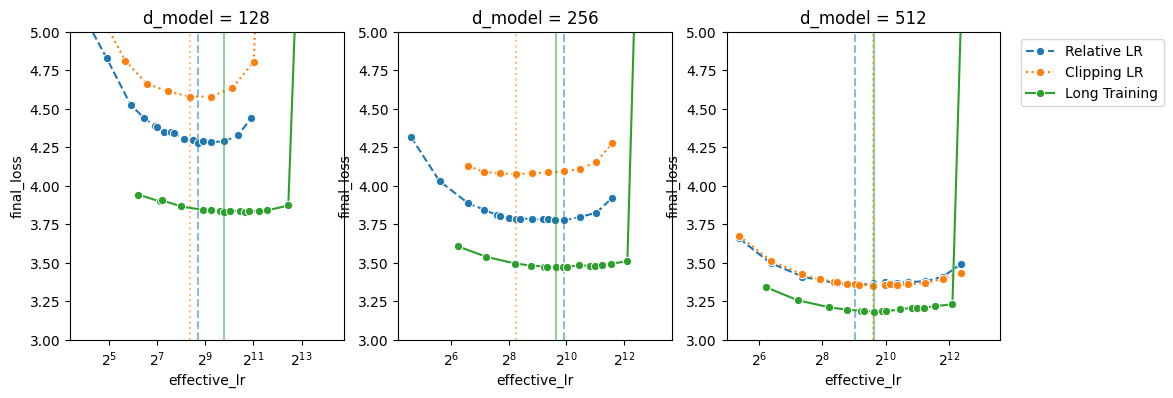

In [9]:
# plot relative versus clipping learning rate loss
fig, axs = plt.subplots(1, 3, figsize=(12, 4))

axs = axs.flatten()

for i, d_model in enumerate([128, 256, 512]):
    ax = axs[i]
    ax.set_title(f"d_model = {d_model}")
    
    # -------------------------------------------------------------
    # 1. Relative LR Curve + Vertical Line
    # -------------------------------------------------------------
    data_rel = df_best_runs_relative[df_best_runs_relative['d_model'] == d_model]
    sns.lineplot(
        data=data_rel, x='effective_lr', y='final_loss', ax=ax,
        marker='o', linestyle='--', label='Relative LR'
    )
    # Grab the color of the line just plotted and apply it to the vline
    color_rel = ax.lines[-1].get_color()
    
    lr_rel = df_optimal_lrs_relative.loc[df_optimal_lrs_relative['d_model'] == d_model, 'effective_lr'].item()
    ax.axvline(x=lr_rel, linestyle='--', color=color_rel, alpha=0.5)
    
    # -------------------------------------------------------------
    # 2. Clipping LR Curve + Vertical Line
    # -------------------------------------------------------------
    cond_clip = (df_best_runs_not_relative['n_training_tokens'] != 5.84630272e+09) & (df_best_runs_not_relative['d_model'] == d_model)
    sns.lineplot(
        data=df_best_runs_not_relative[cond_clip], x='effective_lr', y='final_loss', ax=ax,
        marker='o', linestyle=':', label='Clipping LR'
    )
    color_clip = ax.lines[-1].get_color()
    
    cond_opt_clip = (df_optimal_lrs_not_relative['d_model'] == d_model) & (df_optimal_lrs_not_relative['n_training_tokens'] != 5.84630272e+09)
    lr_clip = df_optimal_lrs_not_relative.loc[cond_opt_clip, 'effective_lr'].item()
    ax.axvline(x=lr_clip, linestyle=':', color=color_clip, alpha=0.5)
    
    # -------------------------------------------------------------
    # 3. Long Training Curve + Vertical Line
    # -------------------------------------------------------------
    cond_long = (df_best_runs_not_relative['n_training_tokens'] == 5.84630272e+09) & (df_best_runs_not_relative['d_model'] == d_model)
    sns.lineplot(
        data=df_best_runs_not_relative[cond_long], x='effective_lr', y='final_loss', ax=ax,
        marker='o', linestyle='-', label='Long Training'
    )
    color_long = ax.lines[-1].get_color()
    
    cond_opt_long = (df_optimal_lrs_not_relative['d_model'] == d_model) & (df_optimal_lrs_not_relative['n_training_tokens'] == 5.84630272e+09)
    lr_long = df_optimal_lrs_not_relative.loc[cond_opt_long, 'effective_lr'].item()
    ax.axvline(x=lr_long, linestyle='-', color=color_long, alpha=0.5)

    ax.set_xscale('log', base=2)
    ax.set_ylim(3, 5)

    # Clean up legends
    if i == 2:
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    else:
        ax.get_legend().remove()



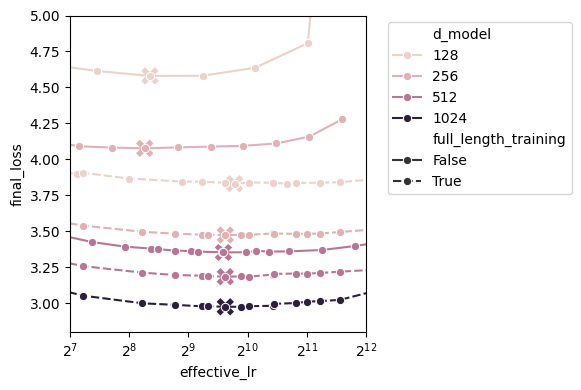

In [14]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))

# final loss
sns.lineplot(df_best_runs_not_relative,
    x="effective_lr",
    y="final_loss",
    hue='d_model',
    style='full_length_training',
    ax=ax,
    marker='o',
    )

sns.scatterplot(
    df_optimal_lrs_not_relative,
    x='effective_lr',
    y='final_loss',
    hue='d_model',
    ax=ax,
    marker='X',
    legend=False,
    s=200,
)

ax.set_xscale('log', base=2)
ax.set_xlim(2**7, 2**12)
ax.set_ylim(2.8, 5)

# Place outside the chart to the right
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()